# Phase 2 — Maritime Graph Construction
Builds a K-nearest-neighbor port graph from `ports_clean.csv`.

- Filters out 'Very Small' harbors (keep Small/Medium/Large only)
- Connects each port to its K nearest neighbors using great-circle (haversine) distance
- Saves graph as `data/processed/maritime_graph.gpickle`

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.neighbors import BallTree
import pickle
import os

PROCESSED_DIR = "../data/processed"

ports = pd.read_csv(f"{PROCESSED_DIR}/ports_clean.csv")
print("Loaded:", ports.shape)
print(ports['harbor_size'].value_counts())

Loaded: (3824, 26)
harbor_size
Very Small    2135
Small         1030
Medium         366
Large          171
               122
Name: count, dtype: int64


In [5]:
# Filter to Small / Medium / Large harbors only (drop 'Very Small' and 'Unknown')
KEEP_SIZES = ['Small', 'Medium', 'Large']
ARCTIC_CUTOFF_LAT = 66.5  # Arctic Circle — exclude non-commercial ice-bound routes

ports_f = ports[
    (ports['harbor_size'].isin(KEEP_SIZES)) &
    (ports['latitude'] < ARCTIC_CUTOFF_LAT)
].reset_index(drop=True)

print(f"Filtered from {len(ports)} to {len(ports_f)} ports")
print(ports_f['harbor_size'].value_counts())

Filtered from 3824 to 1544 ports
harbor_size
Small     1013
Medium     361
Large      170
Name: count, dtype: int64


In [6]:
# --- Compute K-nearest-neighbors using haversine distance (great-circle, accounts for Earth's curvature) ---
K = 10  # slightly higher, was 8
MAX_EDGE_DISTANCE_NM = 2200  # was 1200 — allows legitimate open-ocean crossings now that Arctic routes are excluded
EARTH_RADIUS_NM = 3440.065  # nautical miles


# BallTree with haversine metric requires radians
coords_rad = np.radians(ports_f[['latitude', 'longitude']].values)

tree = BallTree(coords_rad, metric='haversine')

# query K+1 because the nearest neighbor of a point is itself
distances, indices = tree.query(coords_rad, k=K + 1)

# convert distances from radians to nautical miles
distances_nm = distances * EARTH_RADIUS_NM

print("Shape:", distances_nm.shape)
print("Sample distances (nm) for port 0:", distances_nm[0])

Shape: (1544, 11)
Sample distances (nm) for port 0: [  0.         175.29652837 269.2567047  270.11494374 340.1745427
 363.62475989 416.86730564 429.41833223 440.49340718 470.84513283
 495.74376215]


In [7]:
# --- Build the graph ---

G = nx.Graph()

# Add nodes with attributes
for idx, row in ports_f.iterrows():
    G.add_node(
        int(row['port_id']),
        port_name=row['port_name'],
        country=row['country'],
        water_body=row['water_body'],
        latitude=row['latitude'],
        longitude=row['longitude'],
        harbor_size=row['harbor_size'],
        harbor_type=row['harbor_type'],
        max_vessel_draft_m=row['max_vessel_draft_m'],
        cargo_pier_depth_m=row['cargo_pier_depth_m'],
        has_container=row['has_container']
    )

# --- New rules: block phantom land-crossing edges and unrealistic high-latitude long hops ---
HIGH_LAT_THRESHOLD = 45.0
HIGH_LAT_MAX_EDGE_NM = 1200  # tighter cap above 45°N, closes the sub-Arctic North Pacific shortcut gap

PACIFIC_KEYWORDS = ["pacific"]
ATLANTIC_GULF_CARIBBEAN_KEYWORDS = ["gulf of mexico", "caribbean"]
CANAL_TRANSIT_MAX_NM = 60  # allows genuine short canal-zone hops through

def crosses_land_barrier(water_body_a, water_body_b, dist_nm):
    wa = str(water_body_a).lower()
    wb = str(water_body_b).lower()
    a_pacific = any(k in wa for k in PACIFIC_KEYWORDS)
    b_pacific = any(k in wb for k in PACIFIC_KEYWORDS)
    a_atlantic_side = any(k in wa for k in ATLANTIC_GULF_CARIBBEAN_KEYWORDS)
    b_atlantic_side = any(k in wb for k in ATLANTIC_GULF_CARIBBEAN_KEYWORDS)

    crosses = (a_pacific and b_atlantic_side) or (b_pacific and a_atlantic_side)
    if crosses and dist_nm > CANAL_TRANSIT_MAX_NM:
        return True
    return False

# Add edges from KNN results (skip self-loops at index 0)
edges_added = 0
edges_blocked_landbarrier = 0
edges_blocked_highlat = 0

for i in range(len(ports_f)):
    src_id = int(ports_f.iloc[i]['port_id'])
    src_row = ports_f.iloc[i]
    for j in range(1, K + 1):
        neighbor_idx = indices[i][j]
        dst_id = int(ports_f.iloc[neighbor_idx]['port_id'])
        dst_row = ports_f.iloc[neighbor_idx]
        dist_nm = float(distances_nm[i][j])

        # Rule 2: tighter cap at high latitudes (replaces the old flat MAX_EDGE_DISTANCE_NM check)
        max_allowed = MAX_EDGE_DISTANCE_NM
        if src_row['latitude'] > HIGH_LAT_THRESHOLD or dst_row['latitude'] > HIGH_LAT_THRESHOLD:
            max_allowed = HIGH_LAT_MAX_EDGE_NM

        if dist_nm > max_allowed:
            edges_blocked_highlat += 1
            continue

        # Rule 1: ocean basin barrier check (new)
        if crosses_land_barrier(src_row['water_body'], dst_row['water_body'], dist_nm):
            edges_blocked_landbarrier += 1
            continue

        if not G.has_edge(src_id, dst_id):
            G.add_edge(src_id, dst_id, distance_nm=dist_nm, base_weight=dist_nm)
            edges_added += 1

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Blocked by land-barrier rule: {edges_blocked_landbarrier}")
print(f"Blocked by high-latitude cap: {edges_blocked_highlat}")

Nodes: 1543
Edges: 9385
Blocked by land-barrier rule: 105
Blocked by high-latitude cap: 19


In [8]:
# --- Sanity checks ---

# Check for isolated nodes (shouldn't exist since every node gets K neighbors, but confirm)
isolated = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolated)}")

# Check connectivity — is the graph one connected component or split into islands?
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")
if len(components) > 1:
    sizes = sorted([len(c) for c in components], reverse=True)
    print(f"Component sizes (top 10): {sizes[:10]}")

Isolated nodes: 0
Number of connected components: 1
Largest component size: 1543


In [9]:
# --- Permanent sanity check: flag any suspiciously long single edges ---
SUSPICIOUS_HOP_THRESHOLD = MAX_EDGE_DISTANCE_NM  # any edge at/near the cap deserves a look
edge_distances = [(u, v, d['distance_nm']) for u, v, d in G.edges(data=True)]
edge_distances.sort(key=lambda x: -x[2])

print("Top 10 longest edges in the graph (sanity check):")
for u, v, dist in edge_distances[:10]:
    print(f"  {G.nodes[u]['port_name']} -> {G.nodes[v]['port_name']}: {dist:.1f} nm")

# Flag if ANY shortest path between a random sample of port pairs looks pathological
import random
random.seed(42)
sample_nodes = random.sample(list(G.nodes()), min(20, G.number_of_nodes()))
print("\nSanity check: sample shortest-path distances (flag anything > 20000nm as suspicious)")
for i in range(0, len(sample_nodes) - 1, 2):
    a, b = sample_nodes[i], sample_nodes[i+1]
    if nx.has_path(G, a, b):
        d = nx.shortest_path_length(G, a, b, weight='base_weight')
        flag = " <-- SUSPICIOUS" if d > 20000 else ""
        print(f"  {G.nodes[a]['port_name']} -> {G.nodes[b]['port_name']}: {d:.0f} nm{flag}")

Top 10 longest edges in the graph (sanity check):
  Napier -> Papeete: 2183.4 nm
  Tauranga -> Papeete: 2166.6 nm
  Mcmurdo Station -> Hobart: 2151.0 nm
  Port Allen -> Point Richmond: 2143.2 nm
  Port Allen -> Oakland: 2143.1 nm
  Port Allen -> San Francisco: 2139.3 nm
  Nawiliwili Bay -> Point Richmond: 2130.9 nm
  Oakland -> Nawiliwili Bay: 2130.8 nm
  Nawiliwili Bay -> San Francisco: 2127.0 nm
  Port Allen -> Eureka: 2118.8 nm

Sanity check: sample shortest-path distances (flag anything > 20000nm as suspicious)
  Tarabulus -> Skikda: 1481 nm
  Butzfleth -> Puerto Barrios: 5575 nm
  Derince Burnu -> Pascagoula: 6604 nm
  Newport -> Ramsgate: 3345 nm
  Bandar Abbas -> Buenaventura: 10855 nm
  Nicaro -> Darwin: 15227 nm
  South Amboy -> Palanca Terminal: 7619 nm
  Al Fujayrah -> Chi-Lung: 4454 nm
  Auckland -> Kushiro Ko: 6229 nm
  Khorramshahr -> Paramaribo: 9714 nm


**Note on connectivity:** KNN graphs can fragment into disconnected 'islands' (e.g. a cluster of Pacific island ports that are each other's nearest neighbors but far from everything else). If we see multiple components above, we'll bridge them in the next cell so routing between any two ports is always possible.

In [10]:
# --- Bridge disconnected components (if any) ---
# Connects each smaller component to the nearest port in the largest component,
# guaranteeing full graph connectivity so any origin-destination route is solvable.

def bridge_components(G, ports_f):
    components = list(nx.connected_components(G))
    if len(components) <= 1:
        print("Graph already fully connected, no bridging needed.")
        return G

    components = sorted(components, key=len, reverse=True)
    main_component = components[0]

    port_lookup = ports_f.set_index('port_id')

    from geopy.distance import great_circle

    bridges_added = 0
    for comp in components[1:]:
        best_pair = None
        best_dist = float('inf')
        for node_a in comp:
            coord_a = (port_lookup.loc[node_a, 'latitude'], port_lookup.loc[node_a, 'longitude'])
            # sample against main component (limit for speed if main component is huge)
            for node_b in list(main_component)[:500]:
                coord_b = (port_lookup.loc[node_b, 'latitude'], port_lookup.loc[node_b, 'longitude'])
                d = great_circle(coord_a, coord_b).nautical
                if d < best_dist:
                    best_dist = d
                    best_pair = (node_a, node_b)

        if best_pair:
            G.add_edge(best_pair[0], best_pair[1], distance_nm=best_dist, base_weight=best_dist)
            bridges_added += 1
            main_component = main_component | comp

    print(f"Bridges added: {bridges_added}")
    print(f"Connected components after bridging: {nx.number_connected_components(G)}")
    return G

G = bridge_components(G, ports_f)

Graph already fully connected, no bridging needed.


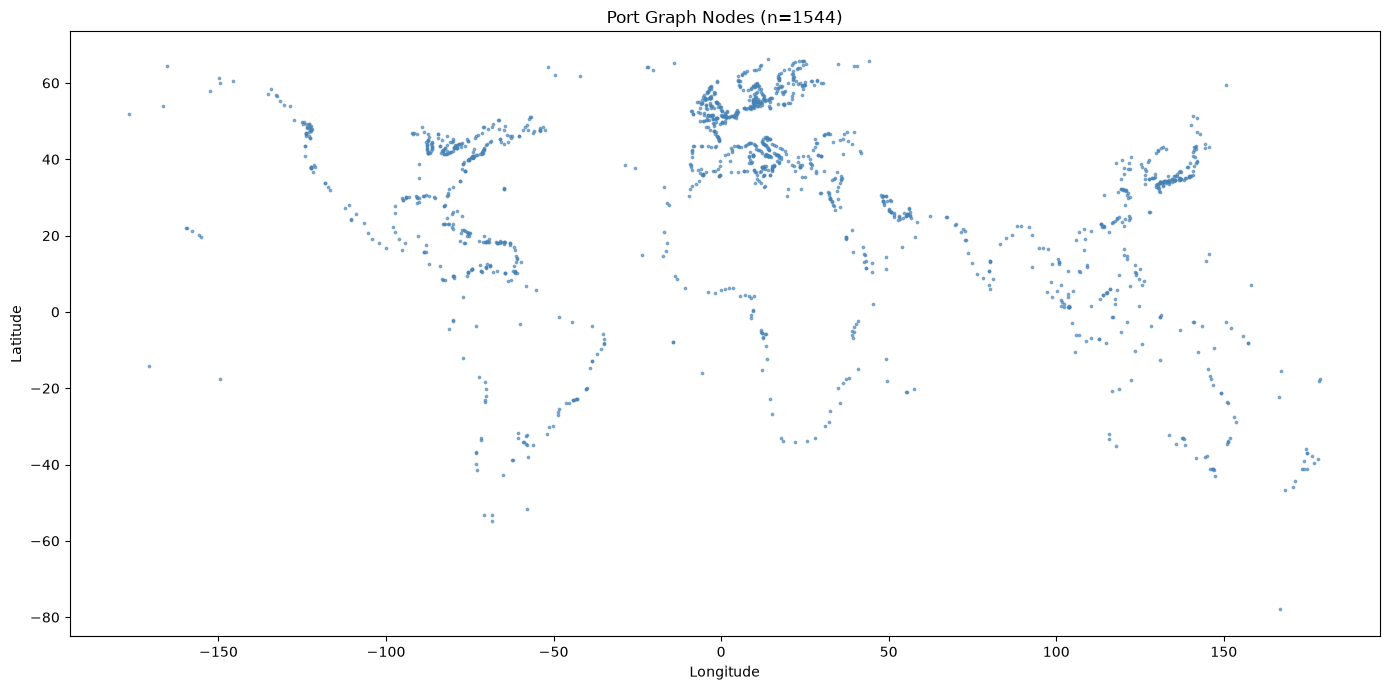

In [11]:
# --- Quick visual sanity check: plot all ports as points ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(ports_f['longitude'], ports_f['latitude'], s=3, alpha=0.6, color='steelblue')
ax.set_title(f"Port Graph Nodes (n={len(ports_f)})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("port_map_preview.png", dpi=100)
plt.show()

In [12]:
# --- Save graph ---
output_path = f"{PROCESSED_DIR}/maritime_graph.gpickle"
with open(output_path, 'wb') as f:
    pickle.dump(G, f)

print(f"Graph saved to {output_path}")
print(f"Final: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph saved to ../data/processed/maritime_graph.gpickle
Final: 1543 nodes, 9385 edges
